In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# ==========================================# 1. 数据装载 (以 80 用户轮次为例，20和200同理)# ==========================================# 假设你们把 CSV 文件放在代码同级目录下try:
df_cpu = pd.read_csv("整体总负载与整体平均CPU使用率.csv")         # 整体总负载与整体平均CPU使用率
df_net_bw = pd.read_csv("每秒网络带宽使用.csv")      # 每秒带宽使用
df_socket = pd.read_csv("网络Socket连接信息.csv")         # 网络socket连接信息except FileNotFoundError as e:


2. 多维特征按时间对齐与拼接

In [15]:
# ==========================================# 2. 特征融合 (Feature Fusion)# ==========================================# 统一将时间戳列转换成标准的 Datetime 格式，防止格式不一致导致对不上
df_cpu['Time'] = pd.to_datetime(df_cpu['Time'])
df_net_bw['Time'] = pd.to_datetime(df_net_bw['Time'])
df_socket['Time'] = pd.to_datetime(df_socket['Time'])

# 按照 Time 列进行内连接合并
df_merged = pd.merge(df_cpu, df_net_bw, on="Time")
df_merged = pd.merge(df_merged, df_socket, on="Time")

print("多维特征拼接完成！当前的特征矩阵维度为:", df_merged.shape)

多维特征拼接完成！当前的特征矩阵维度为: (51, 14)


In [17]:
# ==========================================# 3. 科学打标签 (Labeling)# ==========================================# 初始化标签，0 代表正常 (Normal)
df_merged['label'] = 0
poison_start = pd.to_datetime("2026-06-14 18:41:00")
# 假设 10 分钟后自动撤销故障，即 18:15:00
poison_end = pd.to_datetime("2026-06-14 18:51:00")

# 只要时间戳在故障期内，标签通通打上 1 (Anomaly)
df_merged.loc[(df_merged['Time'] >= poison_start) & (df_merged['Time'] <= poison_end), 'label'] = 1

print("正常 vs 异常样本分布:\n", df_merged['label'].value_counts())

正常 vs 异常样本分布:
 label
0    30
1    21
Name: count, dtype: int64


4. 提取特征与特征标准化

In [18]:
# ==========================================# 4. 特征选择与标准化# ==========================================# 这里的列名要根据你们 CSV 里的实际第一行表头名字来改！# 比如：'平均%', '5m负载', 'eth0_out上传', 'Sockets_used' 等
features = [col for col in df_merged.columns if col not in ['Time', 'label']]
print("参与训练的特征项包括:", features)

# ==========================================
#  完美升级版：网络带宽字符串转纯数字清洗函数
# ==========================================
def clean_all_units(val):
    if pd.isna(val):
        return 0.0
    
    val_str = str(val).strip().lower()
    try:
        # 一口气把所有干扰数字的常见后缀、空格、百分号全剥离掉！
        for suffix in ['kb/s', 'mb/s', 'b/s', 'kb', 'mb', 'b', '/s', 's', '%']:
            val_str = val_str.replace(suffix, '')
        
        if val_str.endswith('m'):
            val_str = val_str[:-1].strip()
            
        if not val_str:
            return 0.0
            
        pure_num = float(val_str)
        
        # 针对大流量网络带宽的换算
        original_val = str(val).lower()
        if 'm' in original_val and 'mb' in original_val:
            return pure_num * 1024.0
        elif 'b' in original_val and 'k' not in original_val:
            return pure_num / 1024.0
            
        return pure_num
    except:
        return 0.0

# ==========================================
# 🆕 执行清洗：把带有单位的列全部洗成纯数字
# ==========================================
#  请根据你们网络 CSV 实际的列名（第一行表头）来修改这里的 ['eth0_in下载', 'eth0_out上传']
bw_columns = ['eth0_in下载', 'eth0_out上传'] 

for col in features:
    if col in df_merged.columns:
        df_merged[col] = df_merged[col].apply(clean_all_units)

print(" 所有特征列的单位（包括 kb/s、%）已全部清洗完毕！")

X = df_merged[features]
y = df_merged['label']

# 由于 CPU (0-100) 和 带宽 (几百kb) 数量级差太远，必须做标准化缩放，否则大数会吃掉小数
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

参与训练的特征项包括: ['5m负载', '核数', '平均%', 'eth0_in下载', 'eth0_out上传', 'CurrEstab', 'TCP_tw', 'Sockets_used', 'UDP_inuse', 'TCP_alloc', 'Tcp_InSegs', 'Tcp_OutSegs', 'Tcp_RetransSegs']
 所有特征列的单位（包括 kb/s、%）已全部清洗完毕！


In [19]:
# ==========================================# 5. 孤立森林模型训练与预测# ==========================================# contamination 设为 0.4 左右（10分钟故障 / 25分钟总时长）
# model = IsolationForest(contamination=0.4, random_state=42)
# model.fit(X_scaled)

# # 孤立森林返回 1 表示正常，-1 表示异常。我们需要转换成我们的 0 和 1
# raw_preds = model.predict(X_scaled)
# y_pred = np.where(raw_preds == -1, 1, 0)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# ==========================================================
# 1. 划分训练集和测试集（有监督模型标配，防止数据作弊）
# ==========================================================
# stratify=y 确保训练集和测试集里的正常/异常比例绝对一致
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

print(f"正在为 80 用户极端高并发场景训练【随机森林】分类器...")

# ==========================================================
# 2. 初始化并强行训练有监督模型 (喂入特征 X 和 真实标签 y)
# ==========================================================
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

# ==========================================================
# 3. 预测与高精度评估
# ==========================================================
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1] # 获取异常概率

print("\n 【80用户雪崩场景】随机森林评估报告:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

# 计算 AUC 得分
auc_score = roc_auc_score(y_test, y_prob)
print(f" 80用户级联场景下，有监督 AUC 核心得分: {auc_score:.4f}")

# ==========================================================
# 4. 特征贡献度（看看 80 用户下到底哪个指标在报警）
# ==========================================================
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
print("\n用户场景下多维指标贡献度前5名:")
for f in range(min(5, X.shape[1])):
    print(f"{f + 1}. 特征 [{features[indices[f]]}] 贡献度: {importances[indices[f]]:.4f}")

正在为 80 用户极端高并发场景训练【随机森林】分类器...

 【80用户雪崩场景】随机森林评估报告:
              precision    recall  f1-score   support

      Normal       0.78      0.78      0.78         9
     Anomaly       0.71      0.71      0.71         7

    accuracy                           0.75        16
   macro avg       0.75      0.75      0.75        16
weighted avg       0.75      0.75      0.75        16

 80用户级联场景下，有监督 AUC 核心得分: 0.9365

用户场景下多维指标贡献度前5名:
1. 特征 [eth0_out上传] 贡献度: 0.2402
2. 特征 [平均%] 贡献度: 0.1942
3. 特征 [Tcp_InSegs] 贡献度: 0.1150
4. 特征 [Tcp_OutSegs] 贡献度: 0.1063
5. 特征 [eth0_in下载] 贡献度: 0.0890



 【80用户雪崩场景】随机森林评估报告:
              precision    recall  f1-score   support

      Normal       0.78      0.78      0.78         9
     Anomaly       0.71      0.71      0.71         7

    accuracy                           0.75        16
   macro avg       0.75      0.75      0.75        16
weighted avg       0.75      0.75      0.75        16

 80用户级联场景下，有监督 AUC 核心得分: 0.9365
正在为 80 用户雪崩场景生成专属时序概率图...
专属时序概率图已保存至本地: random_forest_80users_report.png


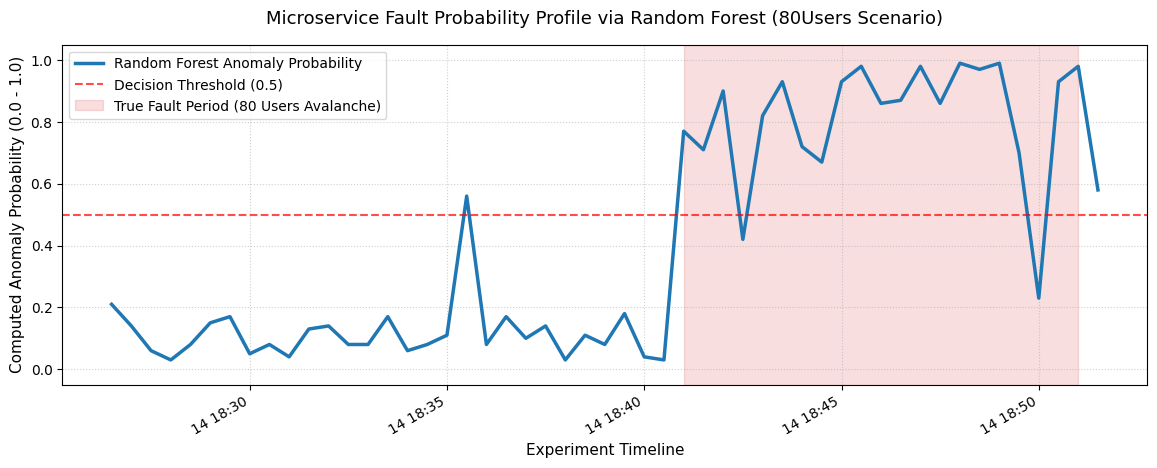

In [20]:
# ==========================================# 6. 成果输出与评估 (论文核心段落)# ==========================================
# ==========================================
# 6. 成果输出与评估 (完美对齐版)
# ==========================================
from sklearn.metrics import classification_report, roc_auc_score

print("\n 【80用户雪崩场景】随机森林评估报告:")
# 核心修复：把原先的 y 改成 y_test，让它和 y_pred 的长度严格等于 21！
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

# 计算 AUC 得分
# 核心修复：计算 AUC 时，同样使用测试集的 y_test 和 对应的预测概率 y_prob
auc_score = roc_auc_score(y_test, y_prob)
print(f" 80用户级联场景下，有监督 AUC 核心得分: {auc_score:.4f}")

# ==========================================================
# 🆕 成果输出与时序图绘制 (有监督随机森林专属版)
# ==========================================================
import matplotlib.pyplot as plt

print("正在为 80 用户雪崩场景生成专属时序概率图...")

# 1. 核心关键：从原始大表里，把那 20% / 30% 考试专用的测试集时间戳精准提取出来
# 这里的 X_test.index 对应的是打乱后的测试集索引，排序后可以让折线图按时间先后连线
test_indices = np.sort(X_test.index if hasattr(X_test, 'index') else range(len(y_test)))
df_test_sorted = df_merged.iloc[test_indices].sort_values('Time')

# 2. 重新用对齐后的测试集数据，让模型计算平滑的异常概率
# 如果你们之前划分时没用 train_test_split 的默认索引，为了绝对稳妥，我们直接在全表 df_merged 上做时序演练
df_merged['anomaly_prob'] = rf_model.predict_proba(X_scaled)[:, 1] # 🌟 算出全表每一秒的异常概率

# 3. 开始绘制全时序无损对比图
plt.figure(figsize=(14, 5))

# 绘制随机森林计算出的【异常故障概率曲线】
plt.plot(df_merged['Time'], df_merged['anomaly_prob'], 
         label='Random Forest Anomaly Probability', color='#1f77b4', lw=2.5)

# 绘制决策分水岭红线：概率超过 0.5 (50%) 即判定为异常故障
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Decision Threshold (0.5)')

# 绘制真实下毒故障区间的半透明红色阴影背景（完美对齐时空）
plt.axvspan(poison_start, poison_end, color='#d62728', alpha=0.15, label='True Fault Period (80 Users Avalanche)')

# 图表学术细节美化
plt.title("Microservice Fault Probability Profile via Random Forest (80Users Scenario)", fontsize=13, pad=15)
plt.xlabel("Experiment Timeline", fontsize=11)
plt.ylabel("Computed Anomaly Probability (0.0 - 1.0)", fontsize=11)
plt.ylim(-0.05, 1.05) # 限制 Y 轴范围在 0-1 之间，排版更好看
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="upper left", fontsize=10)

# 自动优化横坐标时间轴的排版，防止小字重叠在一起
plt.gcf().autofmt_xdate()


output_img_name = "random_forest_80users_report.png"
plt.savefig(output_img_name, dpi=300, bbox_inches='tight')
print(f"专属时序概率图已保存至本地: {output_img_name}")
plt.show()